# OD Analysis

This notebook investigates the effect of bead treatment on optical density (OD) across three experiment types: `96-well`, `24-well`, and `ttubes`. It loads curated OD measurements, computes per-condition summary statistics, and visualizes afternoon-timepoint comparisons against matched no-bead controls.

The goal is to assess whether adding beads shifts OD within each experimental setup, with statistical comparisons made explicit in the figures.

In [8]:
from pathlib import Path

import arcadia_pycolor as apc
import pandas as pd
from od_helpers import (
    plot_od_by_bead,
    plot_od_by_supplement,
    plot_od_by_volume,
    plot_od_cross_experiment,
)

REPO_ROOT = Path().resolve().parent
apc.mpl.setup()

## Data preparation

The measurements are loaded from `data/plate-reader/od-measurements.csv`, where each row is a single replicate. The sample shown below is a quick sanity check that the data were read correctly and that the expected experimental variables are available for filtering and grouping.

In [9]:
csv_path = REPO_ROOT / "data" / "plate-reader" / "od-measurements.csv"
df = pd.read_csv(csv_path)
df.sample(5, random_state=42)

,experiment,strain,volume,time,beads,rep,OD,supplement
33,24-well,SP286,3,morning,4.5,1,1.59,none
6,24-well,SP286,1,morning,0.0,1,1.44,none
182,ttubes,SP286,4,morning,0.0,1,0.82,none
86,96-well,SP286,1,afternoon,0.0,3,0.42,none
156,ttubes,SP286,2,afternoon,4.5,2,10.49,none


## 96-well plate — Afternoon

Each bar shows mean OD across replicates for a given bead size; error bars are approximate 95% confidence intervals (1.96 × SEM). Significance stars mark bead sizes whose OD differs from the no-bead control after Holm-Bonferroni correction.

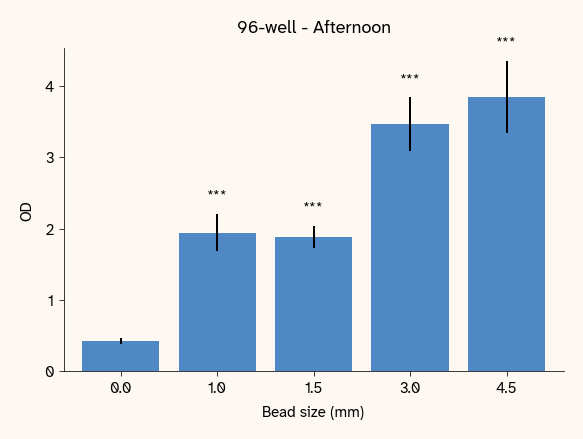

In [10]:
df_96 = df[(df["experiment"] == "96-well") & (df["time"].str.lower() == "afternoon")]
fig_96 = plot_od_by_bead(df_96, "96-well - Afternoon", REPO_ROOT / "figures" / "plate-reader" / "96well_od_bar.svg")

## Volume-stratified comparisons — 24-well and ttubes

The `24-well` and `ttubes` datasets include a volume dimension, so each bead treatment is compared against its matched no-bead control within each volume level rather than pooled across volumes. Bar heights and error bars follow the same convention as above (mean ± 1.96 × SEM); significance stars reflect Holm-Bonferroni-corrected Welch's t-tests across all volume–bead pairs within each dataset.

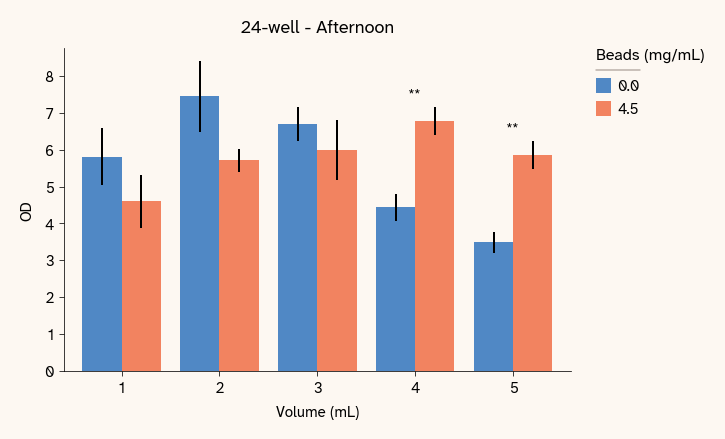

In [11]:
df_24 = df[(df["experiment"] == "24-well") & (df["time"].str.lower() == "afternoon")]
fig_24 = plot_od_by_volume(
    df_24, "24-well - Afternoon", REPO_ROOT / "figures" / "plate-reader" / "24well_od_bar.svg"
)

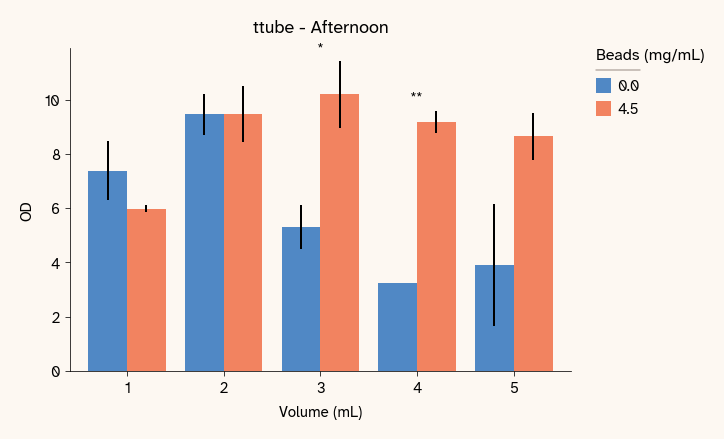

In [12]:
df_tt = df[(df["experiment"].str.lower() == "ttubes") & (df["time"].str.lower() == "afternoon")]
fig_tt = plot_od_by_volume(df_tt, "ttube - Afternoon", REPO_ROOT / "figures" / "plate-reader" / "ttubes_od_bar.svg")

## Supplement experiment — Afternoon

The supplement experiment tests combinations of three additives against an unsupplemented control, all with 4.5 mm beads in 5 mL volume. Supplement abbreviations: **D** = dextrose 3%, **V** = vitamins, **A** = amino acids. Each bar shows mean OD across replicates; error bars are 95% confidence intervals (1.96 × SEM). Significance stars mark supplements whose OD differs from the no-supplement control after Holm-Bonferroni correction.

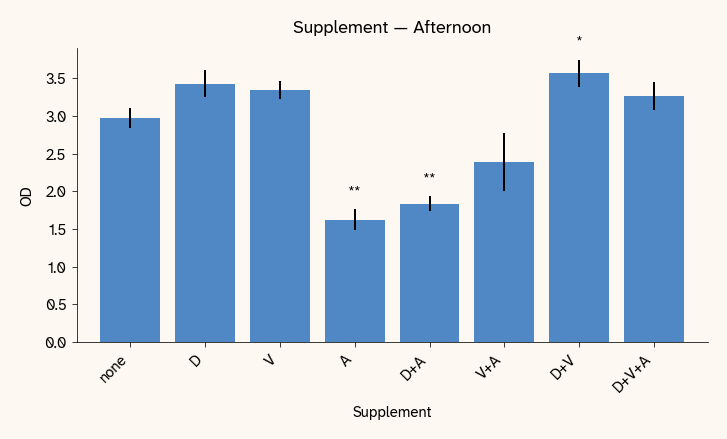

In [13]:
df_supp = df[(df["experiment"] == "supp") & (df["time"].str.lower() == "afternoon")]
fig_supp = plot_od_by_supplement(
    df_supp, "Supplement — Afternoon", REPO_ROOT / "figures" / "plate-reader" / "supp_od_bar.svg"
)

## Cross-experiment comparison

Line plot of mean OD vs. volume across all three experiment types. Shaded bands (or error bars for single points) indicate approximate 95% confidence intervals.

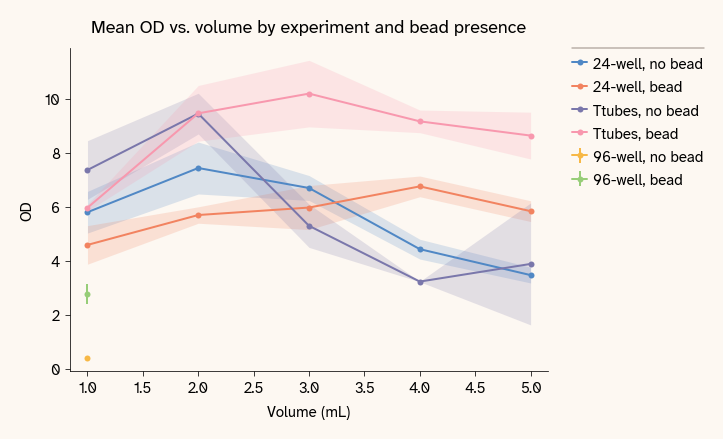

In [14]:
df_agg = pd.concat([df_96, df_tt, df_24])
df_agg["bead_present"] = df_agg["beads"] != 0.0
fig_cross = plot_od_cross_experiment(df_agg, REPO_ROOT / "figures" / "plate-reader" / "aggregate_od_line.svg")